<a href="https://colab.research.google.com/github/gerryfrank10/NLP/blob/main/part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
words = ['hello', 'world', 'i', 'am', 'gerald',
          'and', 'gerald', 'is', 'using', 'torch',
          'to', 'build', 'a', 'character', 'model',
          'also', 'giovanna', 'is', 'my', 'daughter',
          'and', 'she', 'is', 'very', 'cute', 'also',
          'my', 'wife', 'is', 'a', 'loving', 'person',
          'she','takes', 'care', 'of', 'me', 'and', 'our',
          'family','we', 'enjoy', 'spending', 'time', 'together',
          'for', 'some', 'reasons', 'i', 'need', 'to', 'query', 'this']

In [3]:
import string
chars = string.ascii_lowercase
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [4]:
block_size = 3
X, Y = [], []

for w in words:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X, dtype=torch.int64)
Y = torch.tensor(Y, dtype=torch.int64)

hello
... -> h
..h -> e
.he -> l
hel -> l
ell -> o
llo -> .
world
... -> w
..w -> o
.wo -> r
wor -> l
orl -> d
rld -> .
i
... -> i
..i -> .
am
... -> a
..a -> m
.am -> .
gerald
... -> g
..g -> e
.ge -> r
ger -> a
era -> l
ral -> d
ald -> .
and
... -> a
..a -> n
.an -> d
and -> .
gerald
... -> g
..g -> e
.ge -> r
ger -> a
era -> l
ral -> d
ald -> .
is
... -> i
..i -> s
.is -> .
using
... -> u
..u -> s
.us -> i
usi -> n
sin -> g
ing -> .
torch
... -> t
..t -> o
.to -> r
tor -> c
orc -> h
rch -> .
to
... -> t
..t -> o
.to -> .
build
... -> b
..b -> u
.bu -> i
bui -> l
uil -> d
ild -> .
a
... -> a
..a -> .
character
... -> c
..c -> h
.ch -> a
cha -> r
har -> a
ara -> c
rac -> t
act -> e
cte -> r
ter -> .
model
... -> m
..m -> o
.mo -> d
mod -> e
ode -> l
del -> .
also
... -> a
..a -> l
.al -> s
als -> o
lso -> .
giovanna
... -> g
..g -> i
.gi -> o
gio -> v
iov -> a
ova -> n
van -> n
ann -> a
nna -> .
is
... -> i
..i -> s
.is -> .
my
... -> m
..m -> y
.my -> .
daughter
... -> d
..d -> a
.da

In [5]:
import torch.nn.functional as F
import torch.nn as nn

In [6]:
C = torch.randn((27, 2))

In [7]:
C[5], C[5].dtype

(tensor([-0.4407,  0.4655]), torch.float32)

In [8]:
# 1 , 27 x 27, 2 = 1, 2
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # We are typecasting to float to match the dtype of C

tensor([-0.4407,  0.4655])

In [9]:
X.shape, Y.shape

(torch.Size([265, 3]), torch.Size([265]))

In [10]:
C[X]

tensor([[[-2.0674, -0.2932],
         [-2.0674, -0.2932],
         [-2.0674, -0.2932]],

        [[-2.0674, -0.2932],
         [-2.0674, -0.2932],
         [-1.1726, -1.4566]],

        [[-2.0674, -0.2932],
         [-1.1726, -1.4566],
         [-0.4407,  0.4655]],

        ...,

        [[-2.0674, -0.2932],
         [ 0.2164,  2.3712],
         [-1.1726, -1.4566]],

        [[ 0.2164,  2.3712],
         [-1.1726, -1.4566],
         [ 0.8175,  0.5232]],

        [[-1.1726, -1.4566],
         [ 0.8175,  0.5232],
         [ 0.7817, -3.3176]]])

In [11]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  8],
        [ 0,  8,  5],
        [ 8,  5, 12],
        [ 5, 12, 12],
        [12, 12, 15],
        [ 0,  0,  0],
        [ 0,  0, 23],
        [ 0, 23, 15],
        [23, 15, 18],
        [15, 18, 12],
        [18, 12,  4],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 13],
        [ 0,  0,  0],
        [ 0,  0,  7],
        [ 0,  7,  5],
        [ 7,  5, 18],
        [ 5, 18,  1],
        [18,  1, 12],
        [ 1, 12,  4],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 14],
        [ 1, 14,  4],
        [ 0,  0,  0],
        [ 0,  0,  7],
        [ 0,  7,  5],
        [ 7,  5, 18],
        [ 5, 18,  1],
        [18,  1, 12],
        [ 1, 12,  4],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 0,  0,  0],
        [ 0,  0, 21],
        [ 0, 21, 19],
        [21, 19,  9],
        [19,  9, 14],
        [ 9, 14,  7],
        [ 0,  0,  0],
        [ 

In [12]:
C[0], C[0], C[0], C[0], C[0], C[8]

(tensor([-2.0674, -0.2932]),
 tensor([-2.0674, -0.2932]),
 tensor([-2.0674, -0.2932]),
 tensor([-2.0674, -0.2932]),
 tensor([-2.0674, -0.2932]),
 tensor([-1.1726, -1.4566]))

In [13]:
C[X].shape

torch.Size([265, 3, 2])

In [14]:
X[13, 2]

tensor(9)

In [15]:
C[X][13, 2]

tensor([0.8175, 0.5232])

In [16]:
C[9]

tensor([0.8175, 0.5232])

In [17]:
emb = C[X]  # (N, block_size, D)

In [18]:
w1 = torch.randn(size=(6, 100))
b1 = torch.randn(size=(100,))

In [19]:
# We can't do this emb @ w1 + b1 because the dimensions don't match
# We need to reshape emb to (N, block_size * D) to match w1
emb_reshaped = emb.view(emb.shape[0], -1)  # (N, block_size * D)
(emb_reshaped @ w1 + b1).shape  # (N, 100)

torch.Size([265, 100])

In [20]:
h = torch.tanh(emb_reshaped @ w1 + b1)  # (N, 100)
h.shape

torch.Size([265, 100])

In [21]:
W2 = torch.randn(size=(100, 27))
b2 = torch.randn(size=(27,))

In [22]:
logits = h @ W2 + b2  # (N, 27)

In [23]:
logits.shape

torch.Size([265, 27])

In [24]:
counts = logits.exp()

In [25]:
probs = counts / counts.sum(dim=1, keepdim=True)  # (N, 27)

In [26]:
probs[0].sum()

tensor(1.)

In [27]:
Y

tensor([ 8,  5, 12, 12, 15,  0, 23, 15, 18, 12,  4,  0,  9,  0,  1, 13,  0,  7,
         5, 18,  1, 12,  4,  0,  1, 14,  4,  0,  7,  5, 18,  1, 12,  4,  0,  9,
        19,  0, 21, 19,  9, 14,  7,  0, 20, 15, 18,  3,  8,  0, 20, 15,  0,  2,
        21,  9, 12,  4,  0,  1,  0,  3,  8,  1, 18,  1,  3, 20,  5, 18,  0, 13,
        15,  4,  5, 12,  0,  1, 12, 19, 15,  0,  7,  9, 15, 22,  1, 14, 14,  1,
         0,  9, 19,  0, 13, 25,  0,  4,  1, 21,  7,  8, 20,  5, 18,  0,  1, 14,
         4,  0, 19,  8,  5,  0,  9, 19,  0, 22,  5, 18, 25,  0,  3, 21, 20,  5,
         0,  1, 12, 19, 15,  0, 13, 25,  0, 23,  9,  6,  5,  0,  9, 19,  0,  1,
         0, 12, 15, 22,  9, 14,  7,  0, 16,  5, 18, 19, 15, 14,  0, 19,  8,  5,
         0, 20,  1, 11,  5, 19,  0,  3,  1, 18,  5,  0, 15,  6,  0, 13,  5,  0,
         1, 14,  4,  0, 15, 21, 18,  0,  6,  1, 13,  9, 12, 25,  0, 23,  5,  0,
         5, 14, 10, 15, 25,  0, 19, 16,  5, 14,  4,  9, 14,  7,  0, 20,  9, 13,
         5,  0, 20, 15,  7,  5, 20,  8, 

In [28]:
probs.shape

torch.Size([265, 27])

In [29]:
probs[[0,1], Y[0]]  # Probability of the first character in the first word

tensor([4.2269e-12, 2.1412e-10])

In [30]:
probs[torch.arange(probs.shape[0]), Y] # probs[0].shape is 14 as with Y.shape = 14

tensor([4.2269e-12, 8.9845e-10, 1.1590e-18, 1.1279e-13, 2.5936e-01, 1.0719e-12,
        5.3221e-08, 5.6230e-03, 3.4566e-03, 2.7228e-12, 5.1387e-08, 1.7478e-08,
        1.4017e-01, 7.4563e-05, 6.2947e-10, 8.8690e-01, 2.3422e-06, 5.5680e-10,
        8.1310e-13, 2.3313e-11, 1.0606e-12, 1.0033e-08, 1.2835e-11, 8.1031e-10,
        6.2947e-10, 9.3513e-10, 3.5779e-13, 4.5528e-10, 5.5680e-10, 8.1310e-13,
        2.3313e-11, 1.0606e-12, 1.0033e-08, 1.2835e-11, 8.1031e-10, 1.4017e-01,
        5.1360e-08, 9.1579e-05, 3.0033e-04, 7.0911e-07, 1.6343e-10, 2.4236e-07,
        5.4600e-01, 6.4311e-13, 1.5704e-08, 8.8270e-10, 5.9023e-11, 1.5843e-13,
        1.9640e-13, 2.1081e-12, 1.5704e-08, 8.8270e-10, 4.7032e-12, 1.2087e-15,
        1.4193e-03, 3.9038e-01, 2.4987e-07, 1.7380e-09, 1.6399e-10, 6.2947e-10,
        3.8243e-03, 1.4024e-14, 1.8901e-13, 2.4847e-09, 4.0812e-06, 7.8857e-08,
        7.6192e-08, 1.7600e-06, 1.0158e-01, 3.0906e-14, 1.0697e-09, 2.8919e-06,
        5.3571e-05, 5.0670e-09, 2.0593e-

In [31]:
loss = -probs[torch.arange(probs.shape[0]), Y].log().mean()
loss

tensor(17.4612)

## TODO

In [32]:
g = torch.Generator().manual_seed(42)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn(size=(6,100), generator=g)
b1 = torch.randn(size=(100,), generator=g)
W2 = torch.randn(size=(100,27), generator=g)
b2 = torch.randn(size=(27,), generator=g)
parameters = [C, W1, b1, W2, b2]

In [33]:
sum(p.numel() for p in parameters)

3481

In [34]:
for p in parameters:
    p.requires_grad = True  # Enable gradient tracking

In [35]:
# Forward pass
for _ in range(1000):
    emb = C[X]
    h= torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()
    #Update parameters
    for p in parameters:
        # print(p.grad)
        p.data += -0.1 * p.grad  # Gradient descent step

17.425697326660156
15.103192329406738
13.551353454589844
12.47868824005127
11.440555572509766
10.568967819213867
9.960759162902832
9.444302558898926
8.980474472045898
8.563716888427734
8.181438446044922
7.828423500061035
7.503655910491943
7.206610202789307
6.9357781410217285
6.6885504722595215
6.462184429168701
6.254619121551514
6.0644073486328125
5.8902587890625
5.730772018432617
5.584563732147217
5.450396537780762
5.327115058898926
5.213587284088135
5.108705520629883
5.011430740356445
4.920826435089111
4.8360676765441895
4.756450653076172
4.681374549865723
4.610329627990723
4.5428853034973145
4.478676795959473
4.417383670806885
4.358733177185059
4.302483081817627
4.248418807983398
4.196352481842041
4.146117687225342
4.097563743591309
4.05056095123291
4.004992961883545
3.9607577323913574
3.9177680015563965
3.875943899154663
3.835217237472534
3.79552960395813
3.756826400756836
3.719062089920044
3.682194232940674
3.646185874938965
3.6110026836395264
3.576613426208496
3.5429904460906982


In [36]:
values = logits.max(dim=1).indices
values

tensor([ 1,  5, 12, 12, 15,  0,  1, 15, 18, 12,  4,  0,  1, 19,  1, 14,  0,  1,
         5, 18,  1, 12,  4,  0,  1, 14,  4,  0,  1,  5, 18,  1, 12,  4,  0,  1,
        19,  0,  1,  5,  9, 14,  7,  0,  1, 15,  0,  3,  8,  0,  1, 15,  0,  1,
        21,  9, 12,  4,  0,  1, 14,  1,  8,  1, 18,  1,  3, 20,  5, 18,  0,  1,
        25,  4,  5, 12,  0,  1, 14, 19, 15,  0,  1,  5, 15, 22,  1, 14, 14,  1,
         0,  1, 19,  0,  1, 25,  0,  1,  1, 21,  7,  8, 20,  5, 18,  0,  1, 14,
         4,  0,  1, 15,  5,  0,  1, 19,  0,  1,  5, 18, 25,  0,  1,  8, 20,  5,
         0,  1, 14, 19, 15,  0,  1, 25,  0,  1, 15,  6,  5,  0,  1, 19,  0,  1,
        14,  1, 15, 22,  9, 14,  7,  0,  1,  5, 18, 19, 15, 14, 19,  1, 15,  5,
         0,  1, 15, 11,  5, 19,  0,  1,  8, 18,  5,  0,  1,  5,  0,  1, 25,  0,
         1, 14,  4,  0,  1,  5, 18,  0,  1, 15, 13,  9, 12, 25,  0,  1, 15,  0,
         1, 14, 10, 15, 25,  0,  1, 15,  5, 14,  4,  9, 14,  7,  0,  1, 15, 13,
         5,  0,  1, 15,  0,  5, 20,  8, 

In [37]:
values2 = logits.max(dim=1).indices
values2

tensor([ 1,  5, 12, 12, 15,  0,  1, 15, 18, 12,  4,  0,  1, 19,  1, 14,  0,  1,
         5, 18,  1, 12,  4,  0,  1, 14,  4,  0,  1,  5, 18,  1, 12,  4,  0,  1,
        19,  0,  1,  5,  9, 14,  7,  0,  1, 15,  0,  3,  8,  0,  1, 15,  0,  1,
        21,  9, 12,  4,  0,  1, 14,  1,  8,  1, 18,  1,  3, 20,  5, 18,  0,  1,
        25,  4,  5, 12,  0,  1, 14, 19, 15,  0,  1,  5, 15, 22,  1, 14, 14,  1,
         0,  1, 19,  0,  1, 25,  0,  1,  1, 21,  7,  8, 20,  5, 18,  0,  1, 14,
         4,  0,  1, 15,  5,  0,  1, 19,  0,  1,  5, 18, 25,  0,  1,  8, 20,  5,
         0,  1, 14, 19, 15,  0,  1, 25,  0,  1, 15,  6,  5,  0,  1, 19,  0,  1,
        14,  1, 15, 22,  9, 14,  7,  0,  1,  5, 18, 19, 15, 14, 19,  1, 15,  5,
         0,  1, 15, 11,  5, 19,  0,  1,  8, 18,  5,  0,  1,  5,  0,  1, 25,  0,
         1, 14,  4,  0,  1,  5, 18,  0,  1, 15, 13,  9, 12, 25,  0,  1, 15,  0,
         1, 14, 10, 15, 25,  0,  1, 15,  5, 14,  4,  9, 14,  7,  0,  1, 15, 13,
         5,  0,  1, 15,  0,  5, 20,  8, 

In [38]:
Y

tensor([ 8,  5, 12, 12, 15,  0, 23, 15, 18, 12,  4,  0,  9,  0,  1, 13,  0,  7,
         5, 18,  1, 12,  4,  0,  1, 14,  4,  0,  7,  5, 18,  1, 12,  4,  0,  9,
        19,  0, 21, 19,  9, 14,  7,  0, 20, 15, 18,  3,  8,  0, 20, 15,  0,  2,
        21,  9, 12,  4,  0,  1,  0,  3,  8,  1, 18,  1,  3, 20,  5, 18,  0, 13,
        15,  4,  5, 12,  0,  1, 12, 19, 15,  0,  7,  9, 15, 22,  1, 14, 14,  1,
         0,  9, 19,  0, 13, 25,  0,  4,  1, 21,  7,  8, 20,  5, 18,  0,  1, 14,
         4,  0, 19,  8,  5,  0,  9, 19,  0, 22,  5, 18, 25,  0,  3, 21, 20,  5,
         0,  1, 12, 19, 15,  0, 13, 25,  0, 23,  9,  6,  5,  0,  9, 19,  0,  1,
         0, 12, 15, 22,  9, 14,  7,  0, 16,  5, 18, 19, 15, 14,  0, 19,  8,  5,
         0, 20,  1, 11,  5, 19,  0,  3,  1, 18,  5,  0, 15,  6,  0, 13,  5,  0,
         1, 14,  4,  0, 15, 21, 18,  0,  6,  1, 13,  9, 12, 25,  0, 23,  5,  0,
         5, 14, 10, 15, 25,  0, 19, 16,  5, 14,  4,  9, 14,  7,  0, 20,  9, 13,
         5,  0, 20, 15,  7,  5, 20,  8, 

In [39]:
itos[values[0].item()], itos[Y[0].item()]

('a', 'h')

In [40]:
''.join([itos[i.item()] for i in values]), ''.join([itos[i.item()] for i in Y])

('aello.aorld.asan.aerald.and.aerald.as.aeing.ao.ch.ao.auild.anaharacter.aydel.anso.aeovanna.as.ay.aaughter.and.aoe.as.aery.ahte.anso.ay.aofe.as.anaoving.aersonsaoe.aokes.ahre.ae.ay.and.aer.aomily.ao.anjoy.aoending.aome.ao.ether.aor.aome.aeasons.asaeed.ao.auery.aois.',
 'hello.world.i.am.gerald.and.gerald.is.using.torch.to.build.a.character.model.also.giovanna.is.my.daughter.and.she.is.very.cute.also.my.wife.is.a.loving.person.she.takes.care.of.me.and.our.family.we.enjoy.spending.time.together.for.some.reasons.i.need.to.query.this.')

In [41]:
''.join([itos[i.item()] for i in values[10:20]]), ''.join([itos[i.item()] for i in Y[10:20]])

('d.asan.aer', 'd.i.am.ger')

In [42]:
# TODO

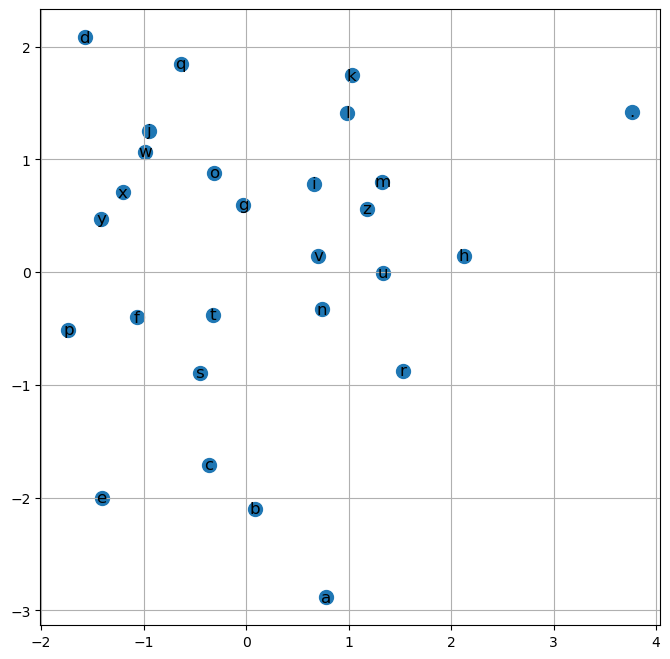

In [44]:
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].detach().numpy(), C[:, 1].detach().numpy(), s=100)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], fontsize=12, ha='center', va='center')
plt.grid('minor')